##PROJECT INTRODUCTION

In [8]:
# =========================================================
# ENTERPRISE-GRADE MULTI-AGENT RAG PIPELINE
# =========================================================
#
# PROJECT TITLE:
# Retrieval-Augmented Generation (RAG) System
# for AI Research Paper Question Answering
#
# =========================================================
# OBJECTIVE
# =========================================================
#
# The objective of this project is to build an
# enterprise-grade Retrieval-Augmented Generation (RAG)
# system capable of:
#
# 1. Loading multiple research papers
# 2. Preprocessing and chunking documents
# 3. Generating semantic embeddings
# 4. Creating vector databases
# 5. Retrieving context-aware information
# 6. Re-ranking retrieved chunks
# 7. Generating grounded academic answers
# 8. Maintaining references and citations
#
# =========================================================
# WHY RAG IS IMPORTANT?
# =========================================================
#
# Traditional LLMs suffer from:
# - Hallucination
# - Outdated knowledge
# - Lack of grounding
#
# RAG solves these issues by:
# - retrieving external knowledge
# - injecting relevant context
# - generating grounded responses
#
# =========================================================
# TECHNOLOGIES USED
# =========================================================
#
# - LangChain
# - ChromaDB
# - HuggingFace Embeddings
# - Groq LLM APIs
# - CrossEncoder Re-ranking
# - Python
#
# =========================================================

##ARCHITECTURE DIAGRAM

In [9]:
# =========================================================
# SYSTEM ARCHITECTURE
# =========================================================
#
#                USER QUERY
#                     ↓
#          QUERY PLANNER AGENT
#                     ↓
#               VECTOR RETRIEVER
#                     ↓
#                CHROMA VECTOR DB
#                     ↓
#              RE-RANKER AGENT
#                     ↓
#                Q&A AGENT
#                     ↓
#             SUMMARIZER AGENT
#                     ↓
#         FINAL ACADEMIC RESPONSE
#
# =========================================================
#
# WHY MULTI-AGENT ARCHITECTURE?
#
# Separating responsibilities into multiple agents:
#
# - improves modularity
# - improves maintainability
# - improves scalability
# - simulates enterprise AI systems
#
# =========================================================

##INSTALL LIBRARIES

In [1]:
# # # =========================================================
# # # STEP 1: INSTALL REQUIRED LIBRARIES
# # # =========================================================

# !pip uninstall -y numpy -q
# !pip install numpy==1.26.4 -q

# !pip install -q \
# langchain==0.2.16 \
# langchain-community==0.2.16 \
# langchain-core==0.2.38 \
# langchain-groq==0.1.9 \
# langchain-text-splitters==0.2.2 \
# chromadb==0.5.5 \
# sentence-transformers==2.7.0 \
# pypdf==4.3.1 \
# tiktoken==0.7.0 \
# transformers==4.44.2 \
# accelerate==0.34.2 \
# pandas \
# matplotlib

##IMPORTANT NOTE

In [2]:
# =========================================================
# IMPORTANT NOTE
# =========================================================
#
# After installation:
#
# 1. Restart Runtime
# 2. Run notebook from beginning
#
# This is required because:
# - transformer libraries reload during runtime
# - NumPy compatibility must refresh
#
# =========================================================

In [3]:
# =========================================================
# STEP 2: IMPORT REQUIRED LIBRARIES
# =========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import CrossEncoder

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_groq import ChatGroq

In [4]:
# =========================================================
# STEP 3: CONFIGURE GROQ API KEY
# =========================================================

os.environ["GROQ_API_KEY"] = ""

In [5]:
# =========================================================
# STEP 4: INITIALIZE LARGE LANGUAGE MODEL
# =========================================================
#
# MODEL:
# llama-3.3-70b-versatile
#
# WHY THIS MODEL?
#
# - Strong reasoning capability
# - Better summarization
# - Better academic response generation
#
# temperature=0
#
# Ensures deterministic outputs.
#
# =========================================================

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0
)

print("LLM Initialized Successfully")

LLM Initialized Successfully


In [6]:
# =========================================================
# STEP 5: LOAD RESEARCH PAPERS
# =========================================================
#
# RESEARCH PAPERS:
#
# 1. Attention Is All You Need
# 2. GPT-3 Paper
# 3. RAG Paper
#
# Metadata is preserved for:
# - traceability
# - explainability
# - citations
#
# =========================================================

pdf_paths = [
    "/content/1706.03762v7.pdf",
    "/content/2005.11401v4.pdf",
    "/content/2005.14165v4.pdf"
]

documents = []

for path in pdf_paths:

    try:

        loader = PyPDFLoader(path)

        docs = loader.load()

        for doc in docs:
            doc.metadata["source_pdf"] = path

        documents.extend(docs)

        print(f"Loaded Successfully: {path}")

    except Exception as e:

        print(f"Error Loading {path}")

        print(e)

print("\nTotal Pages Loaded:", len(documents))

Loaded Successfully: /content/1706.03762v7.pdf
Loaded Successfully: /content/2005.11401v4.pdf
Loaded Successfully: /content/2005.14165v4.pdf

Total Pages Loaded: 109


In [7]:
# =========================================================
# STEP 6: DISPLAY RAW DOCUMENT
# =========================================================
#
# WHY IMPORTANT?
#
# Demonstrates:
# - successful PDF extraction
# - metadata preservation
# - raw text quality
#
# =========================================================

print(documents[0].page_content[:2000])

print("\n" + "="*80)

print("\nMETADATA:\n")

print(documents[0].metadata)

Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.comNoam Shazeer∗
Google Brain
noam@google.comNiki Parmar∗
Google Research
nikip@google.comJakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.comAidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.eduŁukasz Kaiser∗
Google Brain
lukaszkaiser@google.com
Illia Polosukhin∗ ‡
illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer,
based solely on attention mechanisms, dispensing with recurrence and convolutions
entirely. Experime

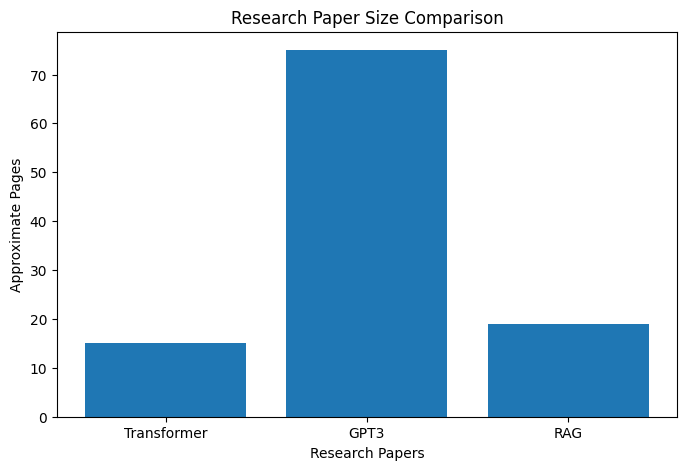

In [8]:
# =========================================================
# STEP 7: VISUALIZE RESEARCH PAPER SIZES
# =========================================================

paper_names = ["Transformer", "GPT3", "RAG"]

page_counts = [15, 75, 19]

plt.figure(figsize=(8,5))

plt.bar(paper_names, page_counts)

plt.xlabel("Research Papers")

plt.ylabel("Approximate Pages")

plt.title("Research Paper Size Comparison")

plt.show()

In [9]:
# =========================================================
# STEP 8: DOCUMENT CHUNKING
# =========================================================
#
# WHY CHUNKING IS REQUIRED?
#
# Large Language Models cannot process extremely
# large documents efficiently.
#
# Therefore:
# - documents are split into smaller chunks
# - semantic continuity is preserved
#
# =========================================================
# CHUNKING STRATEGY
# =========================================================
#
# chunk_size = 1000
#
# WHY?
# Preserves semantic meaning.
#
# chunk_overlap = 200
#
# WHY?
# Prevents context fragmentation between chunks.
#
# =========================================================

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

print("Total Chunks Created:", len(chunks))

Total Chunks Created: 461


In [10]:
# =========================================================
# STEP 9: DISPLAY SAMPLE CHUNK
# =========================================================

print(chunks[0].page_content)

print("\n" + "="*80)

print("\nCHUNK METADATA:\n")

print(chunks[0].metadata)

Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.comNoam Shazeer∗
Google Brain
noam@google.comNiki Parmar∗
Google Research
nikip@google.comJakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.comAidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.eduŁukasz Kaiser∗
Google Brain
lukaszkaiser@google.com
Illia Polosukhin∗ ‡
illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer,
based solely on attention mechanisms, dispensing with recurrence and convolutions


CHUNK METADATA:


In [11]:
# =========================================================
# STEP 10: GENERATE EMBEDDINGS
# =========================================================
#
# WHAT ARE EMBEDDINGS?
#
# Embeddings are vector representations of text.
#
# They help:
# - semantic similarity search
# - contextual retrieval
# - vector search
#
# =========================================================

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding Model Loaded")

/tmp/ipykernel_34462/1434991495.py:16: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  embedding_model = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Model Loaded


In [12]:
# =========================================================
# STEP 11: DISPLAY SAMPLE EMBEDDING VECTOR
# =========================================================

sample_embedding = embedding_model.embed_query(
    "What is Retrieval-Augmented Generation?"
)

print("Embedding Length:", len(sample_embedding))

print("\nFirst 20 Values:\n")

print(sample_embedding[:20])

Embedding Length: 384

First 20 Values:

[-0.11101918667554855, -0.026313433423638344, -0.05789434164762497, 0.05978525057435036, -0.020831579342484474, 0.07061474025249481, 0.044409509748220444, -0.0661303922533989, 0.03184768185019493, -0.033628370612859726, 0.07749314606189728, 0.048896342515945435, 0.05041749030351639, -0.06417163461446762, -0.03989154100418091, -0.010454285889863968, 0.031552236527204514, -0.007679475471377373, -0.030346008017659187, -0.05291774496436119]


In [13]:
# =========================================================
# STEP 12: CREATE CHROMADB VECTOR DATABASE
# =========================================================
#
# WHY VECTOR DATABASE?
#
# Stores:
# - embeddings
# - metadata
# - chunk references
#
# Enables efficient semantic retrieval.
#
# =========================================================

vector_db = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db"
)

vector_db.persist()

print("Vector Database Created Successfully")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Vector Database Created Successfully


/tmp/ipykernel_34462/1788110416.py:22: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vector_db.persist()


In [14]:
# =========================================================
# STEP 13: CREATE RETRIEVER
# =========================================================
#
# The retriever:
#
# 1. Converts query into embeddings
# 2. Performs semantic search
# 3. Retrieves relevant chunks
#
# =========================================================

retriever = vector_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 8}
)

print("Retriever Created Successfully")

Retriever Created Successfully


In [15]:
# =========================================================
# STEP 14: INITIALIZE RE-RANKER
# =========================================================
#
# PROBLEM:
#
# Cosine similarity alone may retrieve
# partially relevant chunks.
#
# SOLUTION:
#
# CrossEncoder Re-ranking
#
# BENEFITS:
# - better contextual alignment
# - improved answer quality
#
# =========================================================

reranker = CrossEncoder(
    'cross-encoder/ms-marco-MiniLM-L-6-v2'
)

print("Re-ranker Loaded Successfully")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Re-ranker Loaded Successfully


In [16]:
# =========================================================
# STEP 15: QUERY PLANNER AGENT
# =========================================================
#
# PURPOSE:
#
# - understand query intent
# - identify keywords
# - determine retrieval strategy
#
# Simulates enterprise orchestration.
#
# =========================================================

def query_planner_agent(query):

    prompt = f'''
    Analyze the query and identify:

    1. Main topic
    2. Important keywords
    3. Retrieval strategy

    Query:
    {query}
    '''

    response = llm.invoke(prompt)

    return response.content

In [17]:
# =========================================================
# STEP 16: RETRIEVE DOCUMENTS
# =========================================================

def retrieve_documents(query):

    docs = retriever.get_relevant_documents(query)

    return docs

In [18]:
# =========================================================
# STEP 17: RETRIEVAL SCORE ANALYSIS
# =========================================================
#
# WHY IMPORTANT?
#
# Demonstrates explainability.
#
# Shows:
# - why chunks were retrieved
# - semantic relevance scores
#
# =========================================================

query = "Explain multi-head attention"

results = vector_db.similarity_search_with_score(query, k=4)

score_data = []

for idx, (doc, score) in enumerate(results):

    print("\n" + "="*80)

    print("Chunk:", idx+1)

    print("Similarity Score:", score)

    print("\nMetadata:")

    print(doc.metadata)

    score_data.append({
        "Chunk": idx+1,
        "Score": score
    })

df_scores = pd.DataFrame(score_data)

print("\nSimilarity Score Table:\n")

print(df_scores)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Chunk: 1
Similarity Score: 0.7870495319366455

Metadata:
{'page': 2, 'source': '/content/1706.03762v7.pdf', 'source_pdf': '/content/1706.03762v7.pdf'}

Chunk: 2
Similarity Score: 0.8203068971633911

Metadata:
{'page': 4, 'source': '/content/1706.03762v7.pdf', 'source_pdf': '/content/1706.03762v7.pdf'}

Chunk: 3
Similarity Score: 0.9124011993408203

Metadata:
{'page': 12, 'source': '/content/1706.03762v7.pdf', 'source_pdf': '/content/1706.03762v7.pdf'}

Chunk: 4
Similarity Score: 0.9217937588691711

Metadata:
{'page': 4, 'source': '/content/1706.03762v7.pdf', 'source_pdf': '/content/1706.03762v7.pdf'}

Similarity Score Table:

   Chunk     Score
0      1  0.787050
1      2  0.820307
2      3  0.912401
3      4  0.921794


In [19]:
# =========================================================
# STEP 18: RE-RANK DOCUMENTS
# =========================================================

def rerank_documents(query, docs):

    pairs = []

    for doc in docs:

        pairs.append([query, doc.page_content])

    scores = reranker.predict(pairs)

    scored_docs = list(zip(scores, docs))

    scored_docs = sorted(
        scored_docs,
        key=lambda x: x[0],
        reverse=True
    )

    top_docs = [doc for score, doc in scored_docs[:4]]

    return top_docs

In [20]:
# =========================================================
# STEP 19: QUESTION ANSWERING AGENT
# =========================================================
#
# PURPOSE:
#
# Generate:
# - grounded answers
# - academic responses
# - citation-aware responses
#
# =========================================================

def qa_agent(query, top_docs):

    context = ""

    references = []

    for doc in top_docs:

        context += doc.page_content + "\n\n"

        references.append(
            f"{doc.metadata['source_pdf']} | Page {doc.metadata['page']}"
        )

    prompt = f'''
    Generate a detailed academic answer.

    Structure:
    1. Introduction
    2. Technical Explanation
    3. Advantages
    4. Conclusion

    Question:
    {query}

    Context:
    {context}
    '''

    response = llm.invoke(prompt)

    final_answer = response.content

    final_answer += "\n\nREFERENCES:\n"

    for ref in references:

        final_answer += f"- {ref}\n"

    return final_answer

In [21]:
# =========================================================
# STEP 20: SUMMARIZER AGENT
# =========================================================
#
# PURPOSE:
#
# Converts long answers into:
# - concise summaries
# - executive explanations
#
# =========================================================

def summarizer_agent(answer):

    prompt = f'''
    Summarize the following answer into concise
    academic summary:

    {answer}
    '''

    response = llm.invoke(prompt)

    return response.content

In [22]:
# =========================================================
# STEP 21: EXECUTE PIPELINE FOR SINGLE QUESTION
# =========================================================
#
# WHY THIS CELL?
#
# Before executing all assignment questions,
# we first test the pipeline on one sample query.
#
# PIPELINE FLOW:
#
# User Query
# ↓
# Query Planner
# ↓
# Retriever
# ↓
# Re-Ranker
# ↓
# Q&A Agent
# ↓
# Summarizer Agent
# ↓
# Final Academic Response
#
# =========================================================

question = "Explain the concept of multi-head attention in Transformer architecture."

print("="*100)

print("USER QUESTION:\n")

print(question)

# =========================================================
# QUERY PLANNER
# =========================================================

planning = query_planner_agent(question)

print("\n" + "="*100)

print("\nQUERY PLANNER OUTPUT:\n")

print(planning)

# =========================================================
# DOCUMENT RETRIEVAL
# =========================================================

retrieved_docs = retrieve_documents(question)

print("\n" + "="*100)

print("\nRETRIEVED DOCUMENTS:", len(retrieved_docs))

for idx, doc in enumerate(retrieved_docs):

    print("\n" + "-"*80)

    print(f"Retrieved Chunk {idx+1}")

    print("\nCONTENT:\n")

    print(doc.page_content[:800])

    print("\nMETADATA:\n")

    print(doc.metadata)

# =========================================================
# RE-RANK DOCUMENTS
# =========================================================

top_docs = rerank_documents(
    question,
    retrieved_docs
)

print("\n" + "="*100)

print("\nTOP RE-RANKED DOCUMENTS:\n")

for idx, doc in enumerate(top_docs):

    print(f"\nTop Chunk {idx+1}")

    print(doc.metadata)

# =========================================================
# GENERATE FINAL ANSWER
# =========================================================

final_answer = qa_agent(
    question,
    top_docs
)

print("\n" + "="*100)

print("\nDETAILED ACADEMIC ANSWER:\n")

print(final_answer)

# =========================================================
# SUMMARIZER AGENT
# =========================================================

summary = summarizer_agent(final_answer)

print("\n" + "="*100)

print("\nFINAL SUMMARY:\n")

print(summary)

USER QUESTION:

Explain the concept of multi-head attention in Transformer architecture.


QUERY PLANNER OUTPUT:

Based on the query, here's the analysis:

1. **Main topic**: The main topic of the query is the Transformer architecture, specifically a component of it called "multi-head attention".

2. **Important keywords**: The important keywords in this query are:
   - "Multi-head attention"
   - "Transformer architecture"
   - "Concept" (implying an explanation is required)

3. **Retrieval strategy**: To answer this query, a suitable retrieval strategy would involve:
   - Searching for academic papers or articles that introduce or explain the Transformer architecture, with a focus on the multi-head attention mechanism.
   - Looking for tutorials, lectures, or online courses that teach deep learning or natural language processing, as these often cover the Transformer model and its components.
   - Consulting technical documentation or implementation guides for popular deep learning fr

/tmp/ipykernel_34462/2137657094.py:7: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use invoke instead.
  docs = retriever.get_relevant_documents(query)




TOP RE-RANKED DOCUMENTS:


Top Chunk 1
{'page': 4, 'source': '/content/1706.03762v7.pdf', 'source_pdf': '/content/1706.03762v7.pdf'}

Top Chunk 2
{'page': 4, 'source': '/content/1706.03762v7.pdf', 'source_pdf': '/content/1706.03762v7.pdf'}

Top Chunk 3
{'page': 2, 'source': '/content/1706.03762v7.pdf', 'source_pdf': '/content/1706.03762v7.pdf'}

Top Chunk 4
{'page': 1, 'source': '/content/1706.03762v7.pdf', 'source_pdf': '/content/1706.03762v7.pdf'}


DETAILED ACADEMIC ANSWER:

**1. Introduction**

The Transformer architecture, introduced in recent years, has revolutionized the field of natural language processing (NLP) by providing a novel approach to sequence-to-sequence tasks. One of the key components of the Transformer is the multi-head attention mechanism, which enables the model to jointly attend to information from different representation subspaces at different positions. In this explanation, we will delve into the concept of multi-head attention, its technical details, adva

Total Retrieved Chunks: 8
Total Re-ranked Chunks: 4


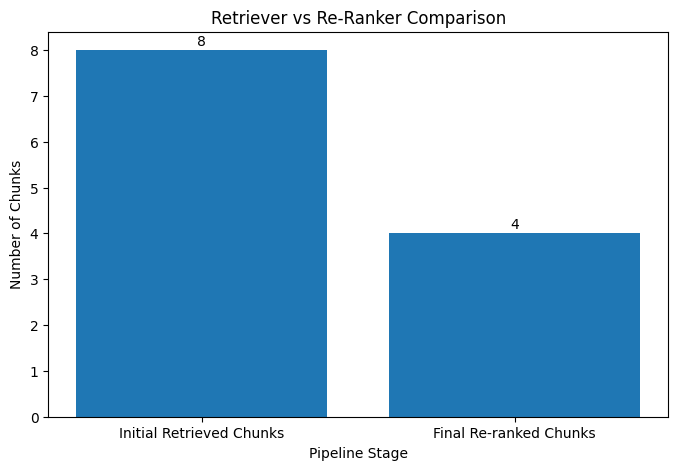

In [26]:
# =========================================================
# STEP 22: VISUALIZE RETRIEVAL vs RE-RANKING
# =========================================================
#
# OBJECTIVE:
#
# This visualization demonstrates:
#
# 1. Total chunks retrieved initially
# 2. Final chunks selected after re-ranking
#
# WHY IMPORTANT?
#
# This shows:
# - retrieval optimization
# - contextual filtering
# - enterprise-grade pipeline behavior
#
# =========================================================

# Sample Question
query = "Explain the concept of multi-head attention in Transformer architecture."

# =========================================================
# INITIAL RETRIEVAL
# =========================================================

retrieved_docs = retrieve_documents(query)

retrieved_count = len(retrieved_docs)

print("Total Retrieved Chunks:", retrieved_count)

# =========================================================
# RE-RANKING
# =========================================================

top_docs = rerank_documents(
    query,
    retrieved_docs
)

reranked_count = len(top_docs)

print("Total Re-ranked Chunks:", reranked_count)

# =========================================================
# VISUALIZATION
# =========================================================

stages = [
    "Initial Retrieved Chunks",
    "Final Re-ranked Chunks"
]

counts = [
    retrieved_count,
    reranked_count
]

plt.figure(figsize=(8,5))

bars = plt.bar(stages, counts)

plt.xlabel("Pipeline Stage")

plt.ylabel("Number of Chunks")

plt.title("Retriever vs Re-Ranker Comparison")

# =========================================================
# DISPLAY VALUES ON TOP OF BARS
# =========================================================

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.1,
        yval,
        ha='center'
    )

plt.show()

In [23]:
# =========================================================
# STEP 23: ALL ASSIGNMENT QUESTIONS
# =========================================================
#
# These are the questions provided in the assignment.
#
# =========================================================

assignment_questions = [

    "What is few-shot learning and how does GPT-3 implement it during inference?",

    "Describe the concept of multi-head attention in Transformer architecture and why it is beneficial.",

    "Explain how positional encoding is implemented in Transformers and why it is necessary.",

    "What are the two sub-layers in each encoder layer of the Transformer model?",

    "What are the main components of the RAG model and how do they interact?"
]

print("Total Assignment Questions:", len(assignment_questions))

Total Assignment Questions: 5


In [24]:
# =========================================================
# STEP 24: EXECUTE COMPLETE PIPELINE
# =========================================================
#
# This cell executes the entire RAG pipeline
# for all assignment questions.
#
# =========================================================

for question in assignment_questions:

    print("\n" + "="*120)

    print("QUESTION:\n")

    print(question)

    # =====================================================
    # QUERY PLANNER
    # =====================================================

    planning = query_planner_agent(question)

    print("\n" + "="*100)

    print("\nQUERY PLAN:\n")

    print(planning)

    # =====================================================
    # RETRIEVE DOCUMENTS
    # =====================================================

    retrieved_docs = retrieve_documents(question)

    print("\n" + "="*100)

    print("\nRETRIEVED DOCUMENTS:", len(retrieved_docs))

    for idx, doc in enumerate(retrieved_docs):

        print("\n" + "-"*80)

        print(f"Retrieved Chunk {idx+1}")

        print("\nCONTENT:\n")

        print(doc.page_content[:700])

        print("\nMETADATA:\n")

        print(doc.metadata)

    # =====================================================
    # RE-RANKING
    # =====================================================

    top_docs = rerank_documents(
        question,
        retrieved_docs
    )

    print("\n" + "="*100)

    print("\nTOP RE-RANKED DOCUMENTS:\n")

    for idx, doc in enumerate(top_docs):

        print(f"\nTop Chunk {idx+1}")

        print(doc.metadata)

    # =====================================================
    # FINAL ANSWER GENERATION
    # =====================================================

    final_answer = qa_agent(
        question,
        top_docs
    )

    print("\n" + "="*100)

    print("\nDETAILED ACADEMIC ANSWER:\n")

    print(final_answer)

    # =====================================================
    # SUMMARIZATION
    # =====================================================

    summary = summarizer_agent(final_answer)

    print("\n" + "="*100)

    print("\nFINAL SUMMARY:\n")

    print(summary)

    print("\n" + "="*120)


QUESTION:

What is few-shot learning and how does GPT-3 implement it during inference?


QUERY PLAN:

Based on the query, here's the analysis:

**1. Main topic:** The main topic of the query is "few-shot learning" and its implementation in GPT-3, a specific artificial intelligence model.

**2. Important keywords:**
The important keywords in the query are:
* "Few-shot learning"
* "GPT-3"
* "Inference"
These keywords are crucial in understanding the context and scope of the query.

**3. Retrieval strategy:**
To answer this query, a retrieval strategy could involve:
* Searching for academic papers or articles that explain few-shot learning and its applications in natural language processing (NLP)
* Looking for documentation or research papers on GPT-3, specifically focusing on its inference capabilities and how it implements few-shot learning
* Checking online resources, such as blogs or forums, that discuss few-shot learning and GPT-3, to gather information on how the model uses this te

In [25]:
#end